# ACTIVIDAD 2: REDES NEURONALES CONVOLUCIONALES

---

En esta actividad, vamos a trabajar con Convolutional Neural Networks para resolver un problema de clasificación de imágenes. En particular, vamos a clasificar diez clases que incluyen fundamentalmente animales y vehículos.

Como las CNN profundas son un tipo de modelo bastante avanzado y computacionalmente costoso, se recomienda hacer la práctica en Google Colaboratory con soporte para GPUs. En [este enlace](https://medium.com/deep-learning-turkey/google-colab-free-gpu-tutorial-e113627b9f5d) se explica cómo activar un entorno con GPUs. *Nota: para leer las imágenes y estandarizarlas al mismo tamaño se usa la librería opencv. Esta ĺibrería está ya instalada en el entorno de Colab, pero si trabajáis de manera local tendréis que instalarla.*

<center><img src="https://production-media.paperswithcode.com/datasets/4fdf2b82-2bc3-4f97-ba51-400322b228b1.png" style="text-align: center" height="300px"></center>

El dataset a utilizar consiste en 60000 imágenes a color de 10 clases de animales y vehículos. El dataset en cuestión se denomina [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) y es más complejo que el dataset MNIST que hemos utilizado en la actividad 1. Aunque tiene las mismas clases (10), los animales y vehículos pueden aparecer en distintas poses, en distintas posiciones de la imagen o con otros animales/ vehículos en pantalla (si bien el elemento a clasificar siempre aparece en la posición predominante).

## Carga de los datos

In [ ]:
import numpy as np
import keras
import matplotlib.pyplot as plt
import pandas as pd
import keras.datasets.cifar10 as cifar10

from tensorflow import keras
from keras.utils import to_categorical

In [ ]:
# Primero, definimos los datos de entrenamiento, validación y prueba
(X, Y), (x_test, y_test) = cifar10.load_data()
(x_train, x_valid) = (X[:40000], X[40000:])
(y_train, y_valid) = (Y[:40000], Y[40000:])

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
# Normalizamos como de costumbre
x_train = x_train / 255.
x_valid = x_valid / 255.
x_test = x_test / 255.

In [ ]:
# Esta variable contiene un mapeo de número de clase a elemento (animal o vehículo).
# La incluimos para ayudarte con la identificación de clases. De ti depende
# si quieres utilizar esta variable o no
MAP_ELEMENTS = {
    0: 'avion', 1: 'coche', 2: 'ave',
    3: 'gato', 4: 'ciervo', 5: 'perro', 6: 'rana',
    7: 'caballo', 8: 'barco', 9: 'camion'
}

In [ ]:
# Función auxiliar para convertir las etiquetas a codificación one-hot
def convert_to_one_hot(labels, num_classes):
    return np.squeeze(np.array([to_categorical(label, num_classes=num_classes) for label in labels]))

# Convertimos las etiquetas de entrenamiento, validación y prueba
num_classes = 10
y_train_one_hot = convert_to_one_hot(y_train, num_classes)
y_valid_one_hot = convert_to_one_hot(y_valid, num_classes)
y_test_one_hot = convert_to_one_hot(y_test, num_classes)

# Verificamos las conversiones
print(y_train_one_hot.shape)
print(y_valid_one_hot.shape)
print(y_test_one_hot.shape)

(40000, 10)
(10000, 10)
(10000, 10)


## Ejercicio

Utilizando Convolutional Neural Networks con Keras, entrenar un clasificador que sea capaz de reconocer una imagen de las incluidas en CIFAR-10 con la mayor accuracy posible. Redactar un informe analizando varias de las alternativas probadas y los resultados obtenidos.

A continuación se detallan una serie de aspectos orientativos que podrían ser analizados en vuestro informe (no es necesario tratar todos ellos ni mucho menos, esto son ideas orientativas de aspectos que podéis explorar):

*   Análisis de los datos a utilizar.
*   Análisis de resultados, obtención de métricas de *precision* y *recall* por clase y análisis de qué clases obtienen mejores o peores resultados.
*   Análisis visual de los errores de la red. ¿Qué tipo de imágenes dan más problemas a nuestro modelo?
*   Comparación de modelos CNNs con un modelo de Fully Connected para este problema.
*   Utilización de distintas arquitecturas CNNs, comentando aspectos como su profundidad, hiperparámetros utilizados, optimizador, uso de técnicas de regularización, *batch normalization*, etc.
*   [ *algo más difícil* ] Utilización de *data augmentation*. Esto puede conseguirse con la clase [ImageDataGenerator](https://keras.io/preprocessing/image/#imagedatagenerator-class) de Keras.

Notas:
* Te recomendamos mantener los conjuntos de entrenamiento, test y prueba que se crean en el Notebook. No obstante, si crees que modificando tales conjuntos puedes lograr mejores resultados (o que puedes lograr los mismos resultados con menos datos, lo cual es también un logro), eres libre de hacerlo.
* No es necesario mostrar en el notebook las trazas de entrenamiento de todos los modelos entrenados, si bien una buena idea seria guardar gráficas de esos entrenamientos para el análisis. Sin embargo, **se debe mostrar el entrenamiento completo del mejor modelo obtenido y la evaluación de los datos de test con este modelo**.

#Resolución

#Activar GPU

Dentro del entorno de ejecución,cambiar el tipo de entorno de ejecución a Acelerador por hardware: GPU.

#1. Imports y carga de datos

In [ ]:
# IMPORTS BÁSICOS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import classification_report, confusion_matrix

import seaborn as sns  # opcional pero útil para la matriz de confusión

# CARGA DE CIFAR-10
import keras.datasets.cifar10 as cifar10

(X, Y), (x_test, y_test) = cifar10.load_data()
(x_train, x_valid) = (X[:40000], X[40000:])
(y_train, y_valid) = (Y[:40000], Y[40000:])

# Normalización
x_train = x_train / 255.0
x_valid = x_valid / 255.0
x_test  = x_test  / 255.0

# Mapeo de clases
MAP_ELEMENTS = {
    0: 'avion', 1: 'coche', 2: 'ave',
    3: 'gato', 4: 'ciervo', 5: 'perro', 6: 'rana',
    7: 'caballo', 8: 'barco', 9: 'camion'
}

# One-hot encoding
def convert_to_one_hot(labels, num_classes):
    return np.squeeze(np.array([to_categorical(label, num_classes=num_classes) for label in labels]))

num_classes = 10
y_train_one_hot = convert_to_one_hot(y_train, num_classes)
y_valid_one_hot = convert_to_one_hot(y_valid, num_classes)
y_test_one_hot  = convert_to_one_hot(y_test,  num_classes)

print("Shapes de las imágenes:")
print("Train:", x_train.shape)
print("Valid:", x_valid.shape)
print("Test :", x_test.shape)

print("Shapes de las etiquetas (one-hot):")
print(y_train_one_hot.shape, y_valid_one_hot.shape, y_test_one_hot.shape)

Shapes de las imágenes:
Train: (40000, 32, 32, 3)
Valid: (10000, 32, 32, 3)
Test : (10000, 32, 32, 3)
Shapes de las etiquetas (one-hot):
(40000, 10) (10000, 10) (10000, 10)


#2. EDA: muestras y distribución de clases

/tmp/ipython-input-3930213480.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(y_train[idx])


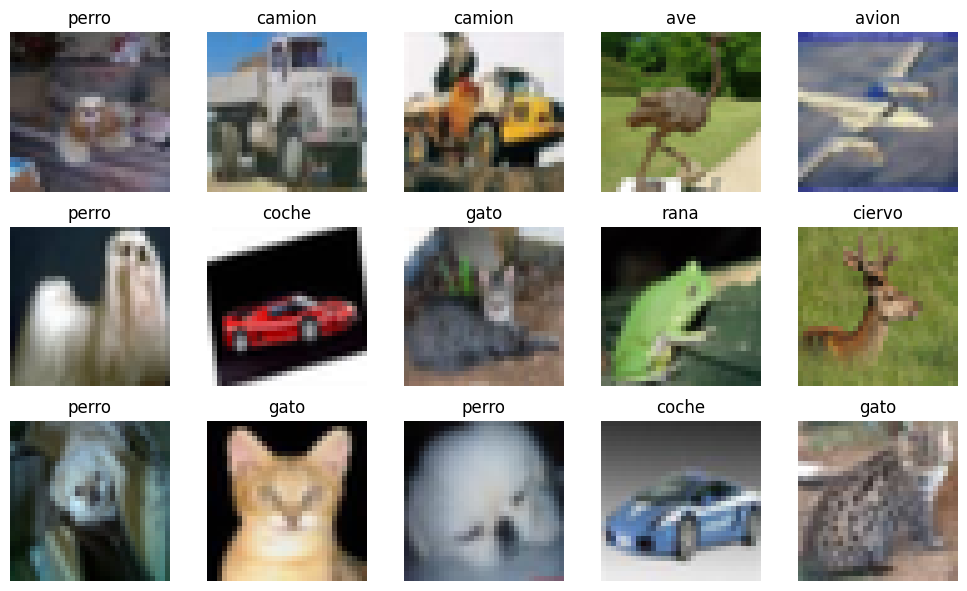

In [ ]:
# Mostrar imágenes de ejemplo
plt.figure(figsize=(10, 6))
for i in range(15):
    idx = np.random.randint(0, x_train.shape[0])
    img = x_train[idx]
    label = int(y_train[idx])
    plt.subplot(3, 5, i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(MAP_ELEMENTS[label])
plt.tight_layout()
plt.show()

Distribución de clases (id : count):
{np.uint8(0): np.int64(3986), np.uint8(1): np.int64(3986), np.uint8(2): np.int64(4048), np.uint8(3): np.int64(3984), np.uint8(4): np.int64(4003), np.uint8(5): np.int64(3975), np.uint8(6): np.int64(4020), np.uint8(7): np.int64(4023), np.uint8(8): np.int64(3997), np.uint8(9): np.int64(3978)}


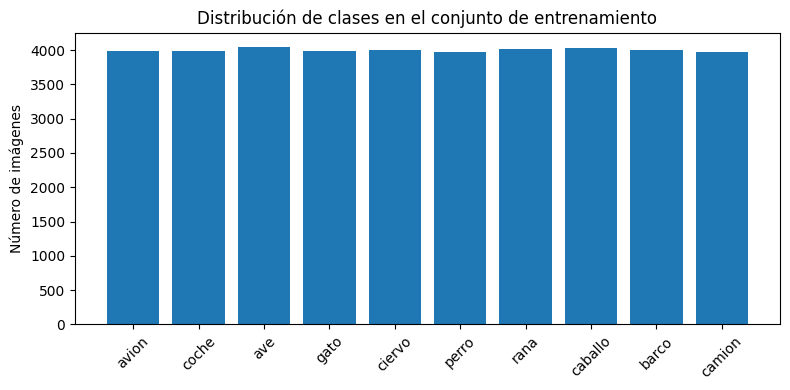

In [ ]:
#Distribución de clases en el conjunto de entrenamiento
unique, counts = np.unique(y_train, return_counts=True)
class_counts = dict(zip(unique.flatten(), counts))
print("Distribución de clases (id : count):")
print(class_counts)

plt.figure(figsize=(8, 4))
plt.bar([MAP_ELEMENTS[i] for i in unique], counts)
plt.xticks(rotation=45)
plt.ylabel("Número de imágenes")
plt.title("Distribución de clases en el conjunto de entrenamiento")
plt.tight_layout()
plt.show()

El dataset CIFAR-10 está formado por imágenes a color de tamaño 32x32 píxeles. En esta práctica se ha dividido el conjunto original en Entrenamiento con 40000 imágenes, Validación con 10000 imágenes y Test con 10000 imágenes.

Cada imagen pertenece a una de las 10 clases definidas: `avion`, `coche`, `ave`, `gato`, `ciervo`, `perro`, `rana`, `caballo`, `barco`, `camion`.

Por medio de la muestra, se puede observar que los objetos (animales y vehículos) pueden aparecer en diferentes posiciones y un poco pixeleado. En algunas imágenes hay más de un objeto, lo que introduce ambigüedad.

La distribución de clases en el conjunto de entrenamiento es equilibrada (4000 imágenes por clase), por lo que no existe un problema siginifcativo de desbalanceo de clases.

Las imágenes han sido normalizadas dividiendo por 255, de forma que los valores de píxel quedan en el rango [0, 1], lo que facilita el entrenamiento de las redes neuronales.

#3. Utilidades para evaluación

In [ ]:
# Función para graficar accuracy y loss
def plot_history(history, title_prefix=""):
    acc = history.history.get('accuracy', [])
    val_acc = history.history.get('val_accuracy', [])
    loss = history.history.get('loss', [])
    val_loss = history.history.get('val_loss', [])

    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Train acc')
    plt.plot(epochs, val_acc, label='Val acc')
    plt.title(f'{title_prefix} Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Train loss')
    plt.plot(epochs, val_loss, label='Val loss')
    plt.title(f'{title_prefix} Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
# Función matriz de confusión
def plot_confusion_matrix(y_true, y_pred, class_names, title="Matriz de confusión"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.title(title)
    plt.xticks(rotation=45)
    plt.yticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [ ]:
# Función para mostrar ejemplos de errores de clasificación
def show_misclassified_images(x, y_true, y_pred, n_images=15):
    mis_idx = np.where(y_true != y_pred)[0]
    if len(mis_idx) == 0:
        print("No hay errores de clasificación con este modelo (raro, pero posible).")
        return

    chosen_idx = np.random.choice(mis_idx, size=min(n_images, len(mis_idx)), replace=False)

    plt.figure(figsize=(10, 6))
    for i, idx in enumerate(chosen_idx):
        img = x[idx]
        real_label = MAP_ELEMENTS[int(y_true[idx])]
        pred_label = MAP_ELEMENTS[int(y_pred[idx])]
        plt.subplot(3, 5, i + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"R:{real_label}\nP:{pred_label}")
    plt.tight_layout()
    plt.show()

#4. Baseline Fully Connected

In [ ]:
# Aplanar imágenes para el modelo Fully Connected
x_train_flat = x_train.reshape((x_train.shape[0], -1))
x_valid_flat = x_valid.reshape((x_valid.shape[0], -1))
x_test_flat  = x_test.reshape((x_test.shape[0],  -1))

print("Shape plano:", x_train_flat.shape)

Shape plano: (40000, 3072)


In [ ]:
# Definición del modelo Fully Connected
model_fc = keras.Sequential([
    layers.Input(shape=(3072,)),          # 32*32*3
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model_fc.compile(optimizer='adam',
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

model_fc.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

Accuracy en test (FC): 0.1114
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Classification report - FC:
              precision    recall  f1-score   support

       avion       0.09      0.13      0.11      1000
       coche       0.10      0.09      0.09      1000
         ave       0.75      0.00      0.01      1000
        gato       0.13      0.50      0.20      1000
      ciervo       0.00      0.00      0.00      1000
       perro       0.00      0.00      0.00      1000
        rana       0.02      0.00      0.01      1000
     caballo       0.00      0.00      0.00      1000
       barco       0.11      0.03      0.05      1000
      camion       0.11      0.36      0.17      1000

    accuracy                           0.11     10000
   macro avg       0.13      0.11      0.06     10000
weighted avg       0.13      0.11      0.06     10000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


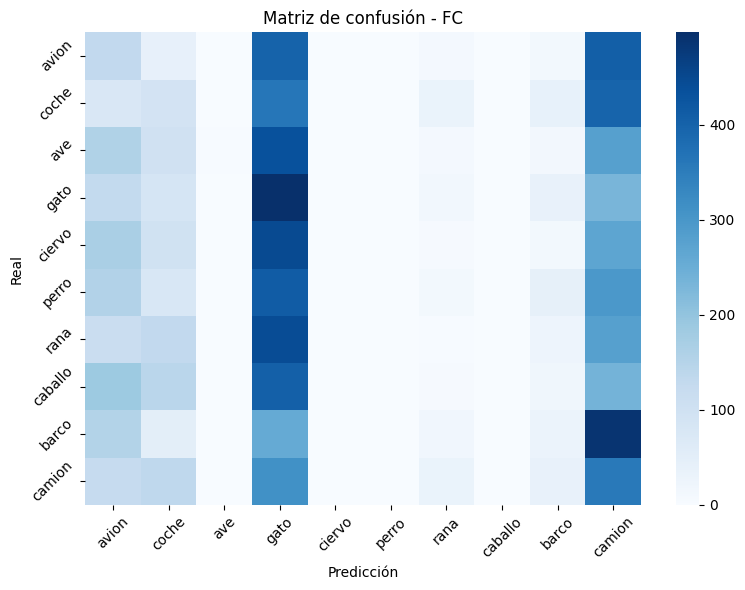

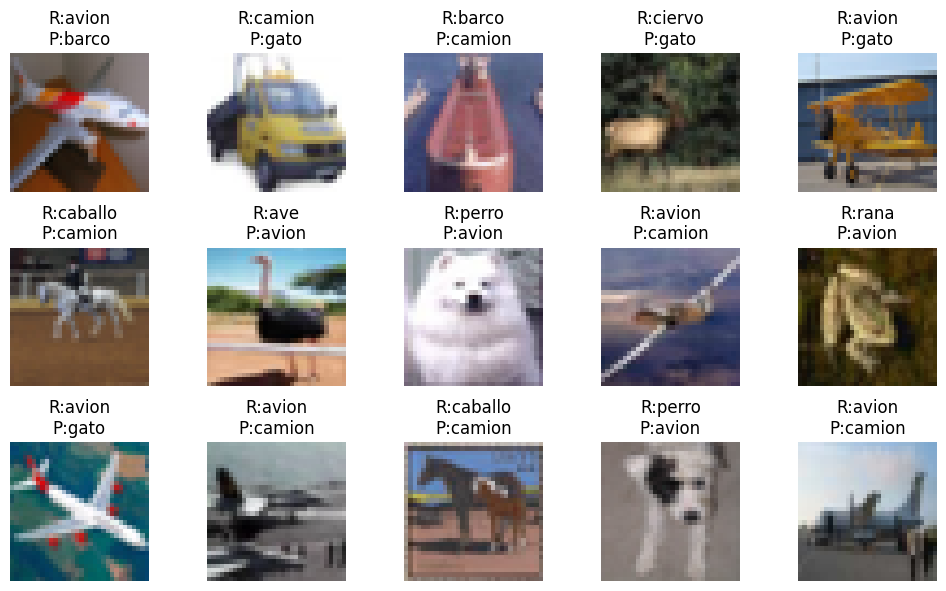

In [ ]:
# Evaluación en test para el modelo Fully Connected
test_loss_fc, test_acc_fc = model_fc.evaluate(x_test_flat, y_test_one_hot, verbose=0)
print(f"Accuracy en test (FC): {test_acc_fc:.4f}")

# Métricas detalladas
y_pred_fc_proba = model_fc.predict(x_test_flat)
y_pred_fc = np.argmax(y_pred_fc_proba, axis=1)
y_true = y_test.flatten()

print("Classification report - FC:")
print(classification_report(
    y_true, y_pred_fc,
    target_names=[MAP_ELEMENTS[i] for i in range(num_classes)]
))

plot_confusion_matrix(
    y_true, y_pred_fc,
    class_names=[MAP_ELEMENTS[i] for i in range(num_classes)],
    title="Matriz de confusión - FC"
)

show_misclassified_images(x_test, y_true, y_pred_fc, n_images=15)

Como punto de partida se ha definido un modelo Fully Connected (sin convoluciones), en el que cada imagen de tamaño 32x32x3 se aplana a un vector de 3072 características. La arquitectura utilizada es: dense layer de 512 neuronas con activación ReLU, una dense layer de 256 neuronas con activación ReLU y un Output layer de 10 neuronas con activación softmax.

Este modelo ignora por completo la estructura espacial de la imagen (no tiene en cuenta que píxeles cercanos suelen estar relacionados), tratando cada píxel como una característica independiente.

El modelo ha alcanzado un accuracy en test de aproximadamente 0.11, muy cercana al rendimiento aleatorio que es de aproximadamente 10%.

El classification report muestra que algunas clases se predicen casi siempre mal y solo unas pocas clases obtienen algo de recall, pero a costa de confundir las otras.

Este comportamiento confirma que una red totalmente conectada muy básica no es adecuada para este problema de visió, ya que no explota la naturaleza espacial de las imágenes.

#5. Primera CNN baseline

In [ ]:
# Definición de una CNN baseline
model_cnn1 = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model_cnn1.compile(optimizer='adam',
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

model_cnn1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20

Epoch 1: val_loss improved from inf to 1.22097, saving model to best_cnn_baseline.h5


625/625 - 8s - 13ms/step - accuracy: 0.4698 - loss: 1.4709 - val_accuracy: 0.5713 - val_loss: 1.2210
Epoch 2/20

Epoch 2: val_loss improved from 1.22097 to 1.04905, saving model to best_cnn_baseline.h5


625/625 - 3s - 4ms/step - accuracy: 0.6163 - loss: 1.0958 - val_accuracy: 0.6349 - val_loss: 1.0490
Epoch 3/20

Epoch 3: val_loss improved from 1.04905 to 0.97370, saving model to best_cnn_baseline.h5


625/625 - 3s - 4ms/step - accuracy: 0.6673 - loss: 0.9560 - val_accuracy: 0.6678 - val_loss: 0.9737
Epoch 4/20

Epoch 4: val_loss improved from 0.97370 to 0.96078, saving model to best_cnn_baseline.h5


625/625 - 3s - 5ms/step - accuracy: 0.7002 - loss: 0.8614 - val_accuracy: 0.6725 - val_loss: 0.9608
Epoch 5/20

Epoch 5: val_loss improved from 0.96078 to 0.88734, saving model to best_cnn_baseline.h5


625/625 - 3s - 4ms/step - accuracy: 0.7234 - loss: 0.7885 - val_accuracy: 0.7005 - val_loss: 0.8873
Epoch 6/20

Epoch 6: val_loss did not improve from 0.88734
625/625 - 3s - 5ms/step - accuracy: 0.7475 - loss: 0.7206 - val_accuracy: 0.6985 - val_loss: 0.8997
Epoch 7/20

Epoch 7: val_loss improved from 0.88734 to 0.87173, saving model to best_cnn_baseline.h5


625/625 - 3s - 4ms/step - accuracy: 0.7722 - loss: 0.6565 - val_accuracy: 0.7059 - val_loss: 0.8717
Epoch 8/20

Epoch 8: val_loss did not improve from 0.87173
625/625 - 3s - 4ms/step - accuracy: 0.7935 - loss: 0.5948 - val_accuracy: 0.6905 - val_loss: 0.9384
Epoch 9/20

Epoch 9: val_loss did not improve from 0.87173
625/625 - 3s - 5ms/step - accuracy: 0.8132 - loss: 0.5370 - val_accuracy: 0.7079 - val_loss: 0.9068
Epoch 10/20

Epoch 10: val_loss did not improve from 0.87173
625/625 - 3s - 4ms/step - accuracy: 0.8329 - loss: 0.4755 - val_accuracy: 0.7081 - val_loss: 0.9351


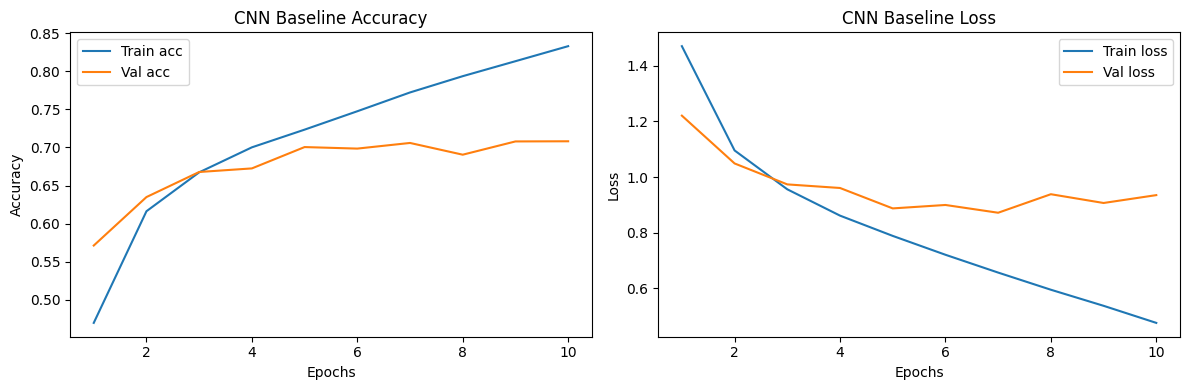

In [ ]:
# Callbacks para evitar overfitting
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

checkpoint_cnn1 = ModelCheckpoint(
    'best_cnn_baseline.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Entrenamiento de la CNN baseline
history_cnn1 = model_cnn1.fit(
    x_train, y_train_one_hot,
    validation_data=(x_valid, y_valid_one_hot),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop, checkpoint_cnn1],
    verbose=2
)

plot_history(history_cnn1, title_prefix="CNN Baseline")

Accuracy en test (CNN baseline): 0.7011
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Classification report - CNN baseline:
              precision    recall  f1-score   support

       avion       0.77      0.69      0.73      1000
       coche       0.84      0.77      0.81      1000
         ave       0.60      0.59      0.60      1000
        gato       0.49      0.57      0.53      1000
      ciervo       0.68      0.64      0.66      1000
       perro       0.59      0.65      0.61      1000
        rana       0.85      0.72      0.78      1000
     caballo       0.79      0.74      0.76      1000
       barco       0.79      0.81      0.80      1000
      camion       0.70      0.83      0.76      1000

    accuracy                           0.70     10000
   macro avg       0.71      0.70      0.70     10000
weighted avg       0.71      0.70      0.70     10000



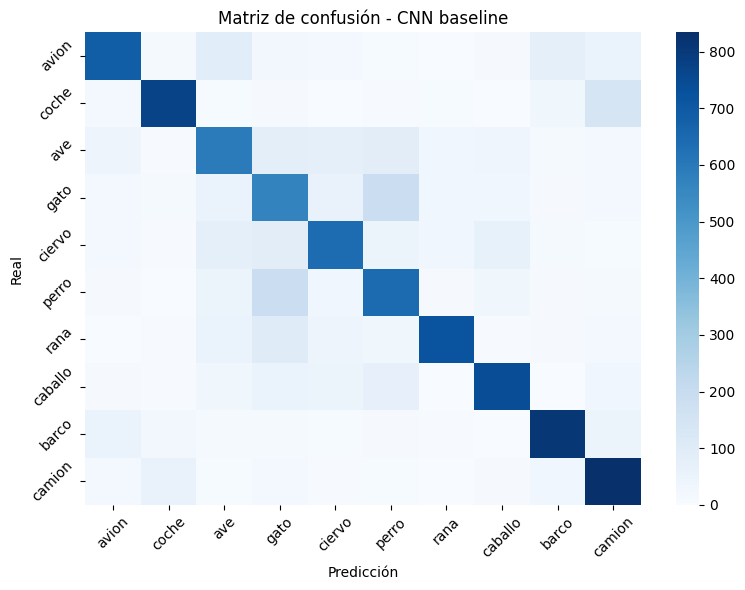

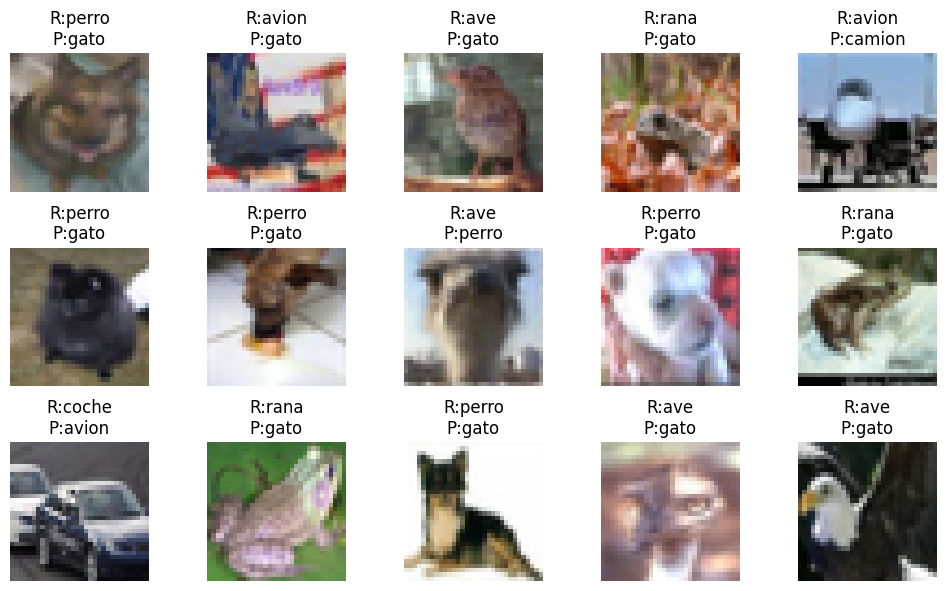

In [ ]:
# Evaluación en test para la CNN baseline
test_loss_cnn1, test_acc_cnn1 = model_cnn1.evaluate(x_test, y_test_one_hot, verbose=0)
print(f"Accuracy en test (CNN baseline): {test_acc_cnn1:.4f}")

y_pred_cnn1_proba = model_cnn1.predict(x_test)
y_pred_cnn1 = np.argmax(y_pred_cnn1_proba, axis=1)
y_true = y_test.flatten()

print("Classification report - CNN baseline:")
print(classification_report(
    y_true, y_pred_cnn1,
    target_names=[MAP_ELEMENTS[i] for i in range(num_classes)]
))

plot_confusion_matrix(
    y_true, y_pred_cnn1,
    class_names=[MAP_ELEMENTS[i] for i in range(num_classes)],
    title="Matriz de confusión - CNN baseline"
)

show_misclassified_images(x_test, y_true, y_pred_cnn1, n_images=15)

Se ha define una primera CNN baseline con la arquitectura Conv2D(32 filtros, kernel 3x3, padding='same') + MaxPooling2D(2x2), Conv2D(64 filtros, kernel 3x3, padding='same') + MaxPooling2D(2x2), Flatten, Dense(128 neuronas, activación ReLU) y un Output layer Dense(10, activación softmax)

El modelo se ha entrenado en 20 epochs usando `Adam` y `EarlyStopping` basado en la pérdida de validación.

Los resultados obtenidos son Accuracy en test de aproximadamente 0.70. Comparándolo con el modelo Fully Connected de aproximadamente 11%, la CNN baseline supone una gran mejora en rendimiento, demostrando la importancia de aprender filtros locales (bordes, texturas, formas simples), reducir la dimensionalidad mediante max-pooling, compartir pesos en la imagen, lo que mejora la capacidad del modelo de generalizar.

El classification report muestra que las clases de vehículos (`coche`, `camion`, `barco`) tienden a obtener mejores métricas. Mientras que algunas clases de animales (`gato`, `perro`, `ave`) son más difíciles y presentan menor precisión y/o recall.

#6. CNN más profunda con BatchNorm + Dropout

In [ ]:
# CNN con regularización
def build_cnn_deep():
    model = keras.Sequential([
        layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model_cnn2 = build_cnn_deep()
model_cnn2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 668,842 (2.55 MB)

 Trainable params: 667,690 (2.55 MB)

 Non-trainable params: 1,152 (4.50 KB)

Epoch 1/30

Epoch 1: val_loss improved from inf to 1.27394, saving model to best_cnn_deep.h5


625/625 - 18s - 30ms/step - accuracy: 0.4537 - loss: 1.6261 - val_accuracy: 0.5458 - val_loss: 1.2739
Epoch 2/30

Epoch 2: val_loss improved from 1.27394 to 0.93264, saving model to best_cnn_deep.h5


625/625 - 5s - 8ms/step - accuracy: 0.6133 - loss: 1.0941 - val_accuracy: 0.6735 - val_loss: 0.9326
Epoch 3/30

Epoch 3: val_loss improved from 0.93264 to 0.85034, saving model to best_cnn_deep.h5


625/625 - 5s - 9ms/step - accuracy: 0.6784 - loss: 0.9115 - val_accuracy: 0.7040 - val_loss: 0.8503
Epoch 4/30

Epoch 4: val_loss improved from 0.85034 to 0.80276, saving model to best_cnn_deep.h5


625/625 - 10s - 17ms/step - accuracy: 0.7087 - loss: 0.8263 - val_accuracy: 0.7239 - val_loss: 0.8028
Epoch 5/30

Epoch 5: val_loss improved from 0.80276 to 0.70636, saving model to best_cnn_deep.h5


...

625/625 - 5s - 9ms/step - accuracy: 0.7838 - loss: 0.6187 - val_accuracy: 0.7921 - val_loss: 0.5969
Epoch 9/30

Epoch 9: val_loss did not improve from 0.59687
625/625 - 5s - 8ms/step - accuracy: 0.7935 - loss: 0.5885 - val_accuracy: 0.7846 - val_loss: 0.6197
Epoch 10/30

Epoch 10: val_loss improved from 0.59687 to 0.57938, saving model to best_cnn_deep.h5


625/625 - 5s - 9ms/step - accuracy: 0.8039 - loss: 0.5626 - val_accuracy: 0.7975 - val_loss: 0.5794
Epoch 11/30

Epoch 11: val_loss improved from 0.57938 to 0.57884, saving model to best_cnn_deep.h5


625/625 - 5s - 8ms/step - accuracy: 0.8134 - loss: 0.5343 - val_accuracy: 0.8020 - val_loss: 0.5788
Epoch 12/30

Epoch 12: val_loss did not improve from 0.57884
625/625 - 5s - 8ms/step - accuracy: 0.8218 - loss: 0.5070 - val_accuracy: 0.7886 - val_loss: 0.6263
Epoch 13/30

Epoch 13: val_loss did not improve from 0.57884
625/625 - 5s - 8ms/step - accuracy: 0.8302 - loss: 0.4861 - val_accuracy: 0.7951 - val_loss: 0.6220
Epoch 14/30

Epoch 14: val_loss improved from 0.57884 to 0.57257, saving model to best_cnn_deep.h5


625/625 - 5s - 8ms/step - accuracy: 0.8325 - loss: 0.4778 - val_accuracy: 0.8075 - val_loss: 0.5726
Epoch 15/30

Epoch 15: val_loss improved from 0.57257 to 0.48280, saving model to best_cnn_deep.h5


625/625 - 5s - 9ms/step - accuracy: 0.8427 - loss: 0.4479 - val_accuracy: 0.8358 - val_loss: 0.4828
Epoch 16/30

Epoch 16: val_loss did not improve from 0.48280
625/625 - 5s - 8ms/step - accuracy: 0.8488 - loss: 0.4322 - val_accuracy: 0.8138 - val_loss: 0.5673
Epoch 17/30

Epoch 17: val_loss did not improve from 0.48280
625/625 - 5s - 8ms/step - accuracy: 0.8508 - loss: 0.4219 - val_accuracy: 0.8236 - val_loss: 0.5272
Epoch 18/30

Epoch 18: val_loss did not improve from 0.48280
625/625 - 5s - 8ms/step - accuracy: 0.8570 - loss: 0.4066 - val_accuracy: 0.8147 - val_loss: 0.5543
Epoch 19/30

Epoch 19: val_loss did not improve from 0.48280
625/625 - 5s - 9ms/step - accuracy: 0.8601 - loss: 0.3966 - val_accuracy: 0.8226 - val_loss: 0.5326
Epoch 20/30

Epoch 20: val_loss did not improve from 0.48280
625/625 - 5s - 8ms/step - accuracy: 0.8650 - loss: 0.3811 - val_accuracy: 0.8261 - val_loss: 0.5306


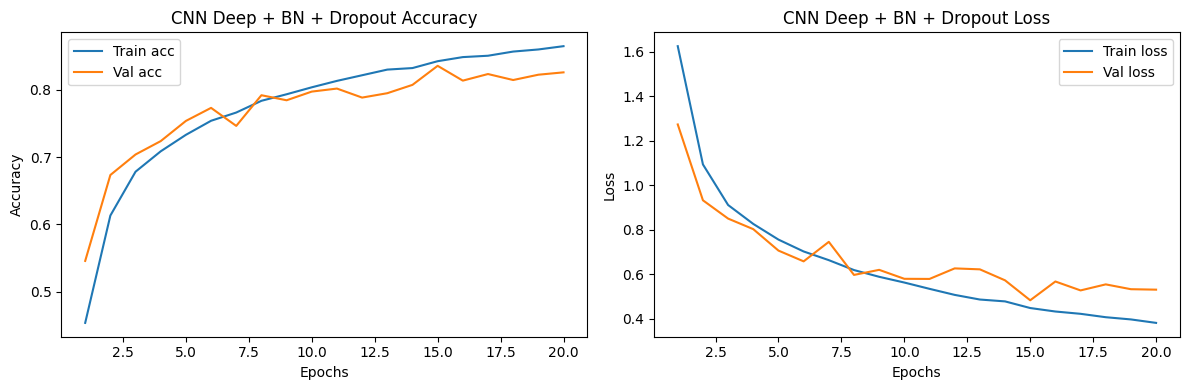

In [ ]:
checkpoint_cnn2 = ModelCheckpoint(
    'best_cnn_deep.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

early_stop2 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_cnn2 = model_cnn2.fit(
    x_train, y_train_one_hot,
    validation_data=(x_valid, y_valid_one_hot),
    epochs=30,
    batch_size=64,
    callbacks=[checkpoint_cnn2, early_stop2],
    verbose=2
)

plot_history(history_cnn2, title_prefix="CNN Deep + BN + Dropout")

Accuracy en test (CNN deep): 0.8273
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Classification report - CNN deep:
              precision    recall  f1-score   support

       avion       0.80      0.85      0.83      1000
       coche       0.90      0.92      0.91      1000
         ave       0.80      0.71      0.75      1000
        gato       0.70      0.65      0.68      1000
      ciervo       0.80      0.82      0.81      1000
       perro       0.77      0.75      0.76      1000
        rana       0.86      0.87      0.87      1000
     caballo       0.88      0.88      0.88      1000
       barco       0.85      0.92      0.88      1000
      camion       0.89      0.89      0.89      1000

    accuracy                           0.83     10000
   macro avg       0.83      0.83      0.83     10000
weighted avg       0.83      0.83      0.83     10000



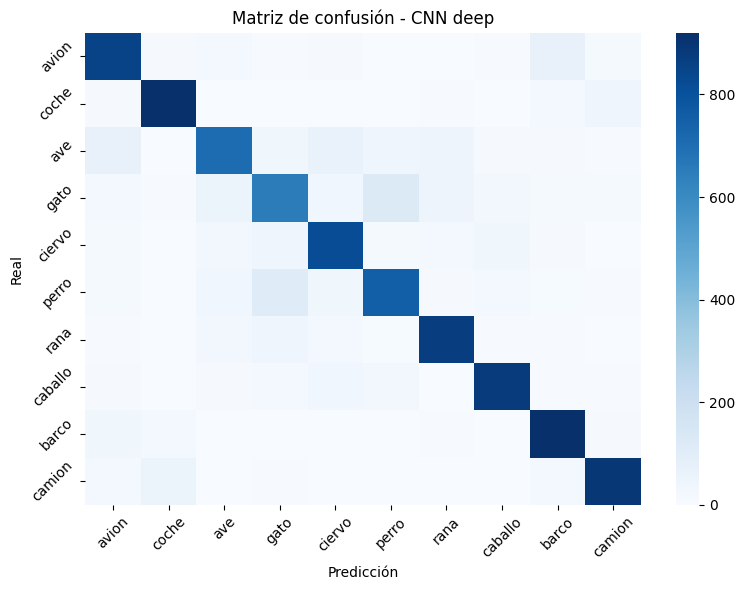

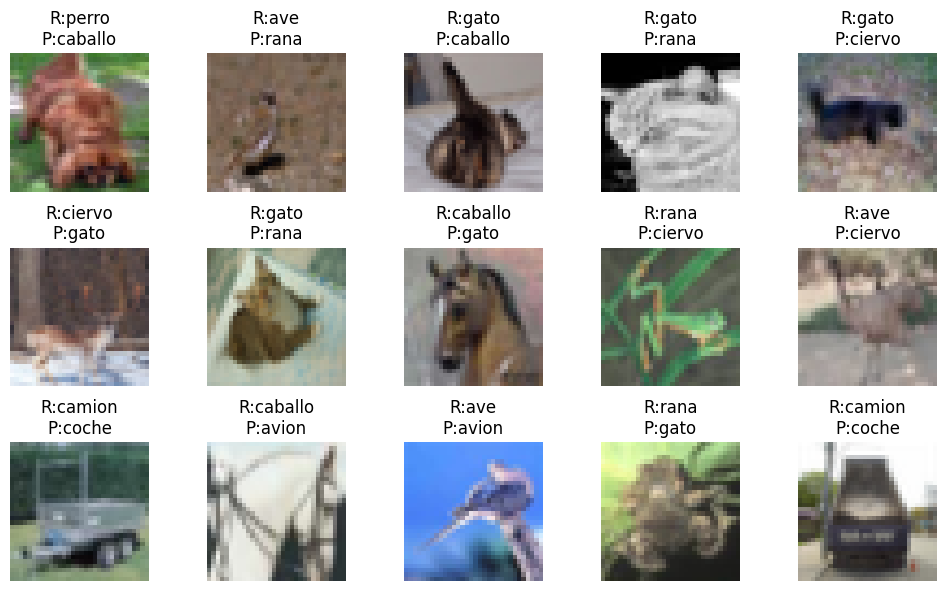

In [ ]:
# Evaluación en subcojunto test para CNN mejorada
test_loss_cnn2, test_acc_cnn2 = model_cnn2.evaluate(x_test, y_test_one_hot, verbose=0)
print(f"Accuracy en test (CNN deep): {test_acc_cnn2:.4f}")

y_pred_cnn2_proba = model_cnn2.predict(x_test)
y_pred_cnn2 = np.argmax(y_pred_cnn2_proba, axis=1)
y_true = y_test.flatten()

print("Classification report - CNN deep:")
print(classification_report(
    y_true, y_pred_cnn2,
    target_names=[MAP_ELEMENTS[i] for i in range(num_classes)]
))

plot_confusion_matrix(
    y_true, y_pred_cnn2,
    class_names=[MAP_ELEMENTS[i] for i in range(num_classes)],
    title="Matriz de confusión - CNN deep"
)

show_misclassified_images(x_test, y_true, y_pred_cnn2, n_images=15)

Posteriormente se ha probado una arquitectura más robusta que incluye tres bloques convolucionales con más filtros (32, 64, 128) y capas Conv2D consecutivas, capas de Batch Normalization tras las convoluciones para estabilizar y acelerar el entrenamiento, capas de Dropout tanto en la parte convolucional como en la parte dense para reducir el sobreajuste, una dense layer intermedia de 256 neuronas antes de la salida.

Este modelo se ha entrenado con el optimizador Adam (`learning_rate=1e-3`), EarlyStopping y ModelCheckpoint para guardar el mejor modelo en validación.

Los resultados dan un Accuracy en test de aproximadamente 0.827. Respecto a la CNN baseline de aproximadamente 70%, se puede observar una mejoría en la capacidad de generalización. La arquitectura que combina Batch Normalization y Dropout permite aprender representaciones más ricas y jerárquicas de las imágenes, controla el sobreajuste, manteniendo una buena performance en el conjunto de test.

Las métricas por clase muestran valores de precisión y recall generalmente superiores al 0.75–0.80 en la mayoría de clases, con buen comportamiento en vehículos (`coche`, `camion`, `barco`) y en `rana` y `caballo`.

#7. Data Augmentation con ImageDataGenerator

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Generador de datos con augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(x_train)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 668,842 (2.55 MB)

 Trainable params: 667,690 (2.55 MB)

...

625/625 - 23s - 37ms/step - accuracy: 0.7887 - loss: 0.6141 - val_accuracy: 0.8133 - val_loss: 0.5390
Epoch 21/40

Epoch 21: val_loss did not improve from 0.53897
625/625 - 23s - 38ms/step - accuracy: 0.7891 - loss: 0.6106 - val_accuracy: 0.7905 - val_loss: 0.6271
Epoch 22/40

Epoch 22: val_loss did not improve from 0.53897
625/625 - 23s - 38ms/step - accuracy: 0.7913 - loss: 0.6023 - val_accuracy: 0.7632 - val_loss: 0.7254
Epoch 23/40

Epoch 23: val_loss did not improve from 0.53897
625/625 - 23s - 37ms/step - accuracy: 0.7952 - loss: 0.5961 - val_accuracy: 0.8065 - val_loss: 0.5782
Epoch 24/40

Epoch 24: val_loss improved from 0.53897 to 0.52747, saving model to best_cnn_aug.h5


625/625 - 23s - 37ms/step - accuracy: 0.7987 - loss: 0.5847 - val_accuracy: 0.8199 - val_loss: 0.5275
Epoch 25/40

Epoch 25: val_loss improved from 0.52747 to 0.52480, saving model to best_cnn_aug.h5


625/625 - 22s - 36ms/step - accuracy: 0.7984 - loss: 0.5869 - val_accuracy: 0.8193 - val_loss: 0.5248
Epoch 26/40

Epoch 26: val_loss did not improve from 0.52480
625/625 - 23s - 37ms/step - accuracy: 0.8015 - loss: 0.5704 - val_accuracy: 0.8163 - val_loss: 0.5501
Epoch 27/40

Epoch 27: val_loss did not improve from 0.52480
625/625 - 23s - 37ms/step - accuracy: 0.8044 - loss: 0.5669 - val_accuracy: 0.8127 - val_loss: 0.5600
Epoch 28/40

Epoch 28: val_loss did not improve from 0.52480
625/625 - 23s - 37ms/step - accuracy: 0.8071 - loss: 0.5634 - val_accuracy: 0.8039 - val_loss: 0.6029
Epoch 29/40

Epoch 29: val_loss improved from 0.52480 to 0.49935, saving model to best_cnn_aug.h5


625/625 - 23s - 37ms/step - accuracy: 0.8100 - loss: 0.5526 - val_accuracy: 0.8330 - val_loss: 0.4994
Epoch 30/40

Epoch 30: val_loss did not improve from 0.49935
625/625 - 24s - 38ms/step - accuracy: 0.8082 - loss: 0.5506 - val_accuracy: 0.7871 - val_loss: 0.6556
Epoch 31/40

Epoch 31: val_loss did not improve from 0.49935
625/625 - 23s - 37ms/step - accuracy: 0.8100 - loss: 0.5451 - val_accuracy: 0.8078 - val_loss: 0.5990
Epoch 32/40

Epoch 32: val_loss improved from 0.49935 to 0.44128, saving model to best_cnn_aug.h5


625/625 - 23s - 37ms/step - accuracy: 0.8124 - loss: 0.5432 - val_accuracy: 0.8494 - val_loss: 0.4413
Epoch 33/40

Epoch 33: val_loss did not improve from 0.44128
625/625 - 23s - 37ms/step - accuracy: 0.8148 - loss: 0.5390 - val_accuracy: 0.8200 - val_loss: 0.5481
Epoch 34/40

Epoch 34: val_loss did not improve from 0.44128
625/625 - 23s - 38ms/step - accuracy: 0.8153 - loss: 0.5351 - val_accuracy: 0.7756 - val_loss: 0.6939
Epoch 35/40

Epoch 35: val_loss did not improve from 0.44128
625/625 - 23s - 37ms/step - accuracy: 0.8181 - loss: 0.5283 - val_accuracy: 0.7994 - val_loss: 0.6182
Epoch 36/40

Epoch 36: val_loss did not improve from 0.44128
625/625 - 41s - 65ms/step - accuracy: 0.8157 - loss: 0.5278 - val_accuracy: 0.8340 - val_loss: 0.4963
Epoch 37/40

Epoch 37: val_loss did not improve from 0.44128
625/625 - 23s - 36ms/step - accuracy: 0.8180 - loss: 0.5201 - val_accuracy: 0.8312 - val_loss: 0.5026
Epoch 38/40

Epoch 38: val_loss did not improve from 0.44128
625/625 - 23s - 37ms/s

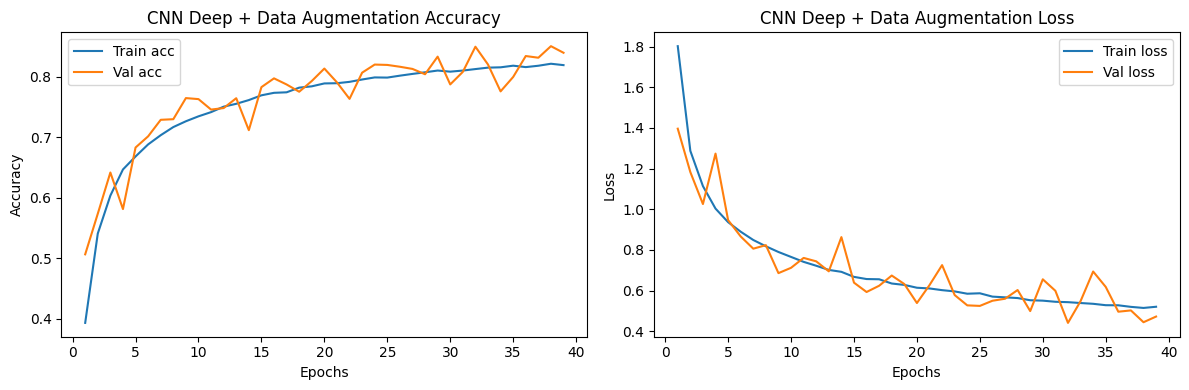

In [ ]:
model_cnn_aug = build_cnn_deep()
model_cnn_aug.summary()

checkpoint_cnn_aug = ModelCheckpoint(
    'best_cnn_aug.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

early_stop_aug = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

batch_size = 64
epochs = 40

history_cnn_aug = model_cnn_aug.fit(
    datagen.flow(x_train, y_train_one_hot, batch_size=batch_size),
    steps_per_epoch=len(x_train) // batch_size,
    epochs=epochs,
    validation_data=(x_valid, y_valid_one_hot),
    callbacks=[checkpoint_cnn_aug, early_stop_aug],
    verbose=2
)

plot_history(history_cnn_aug, title_prefix="CNN Deep + Data Augmentation")

Accuracy en test (CNN deep + augmentation): 0.8433
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Classification report - CNN deep + augmentation:
              precision    recall  f1-score   support

       avion       0.85      0.86      0.86      1000
       coche       0.90      0.95      0.93      1000
         ave       0.87      0.70      0.78      1000
        gato       0.76      0.68      0.72      1000
      ciervo       0.84      0.84      0.84      1000
       perro       0.79      0.77      0.78      1000
        rana       0.78      0.92      0.85      1000
     caballo       0.84      0.90      0.87      1000
       barco       0.95      0.86      0.90      1000
      camion       0.85      0.94      0.89      1000

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



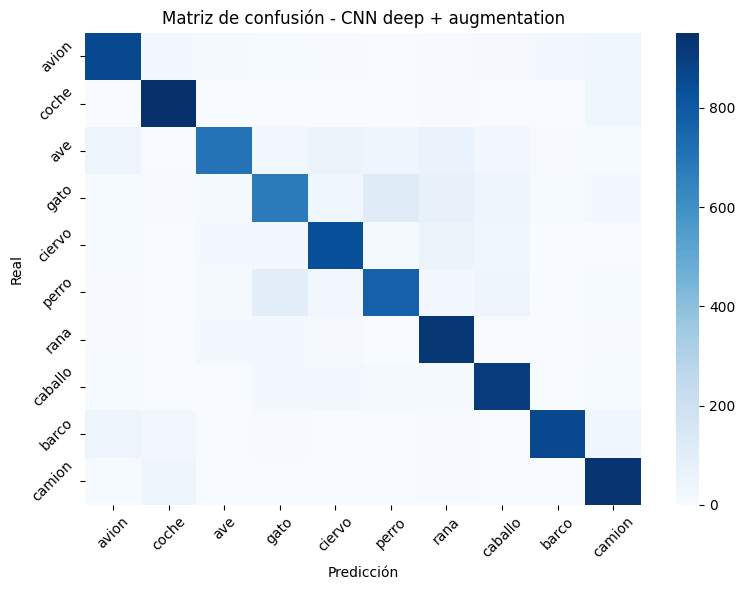

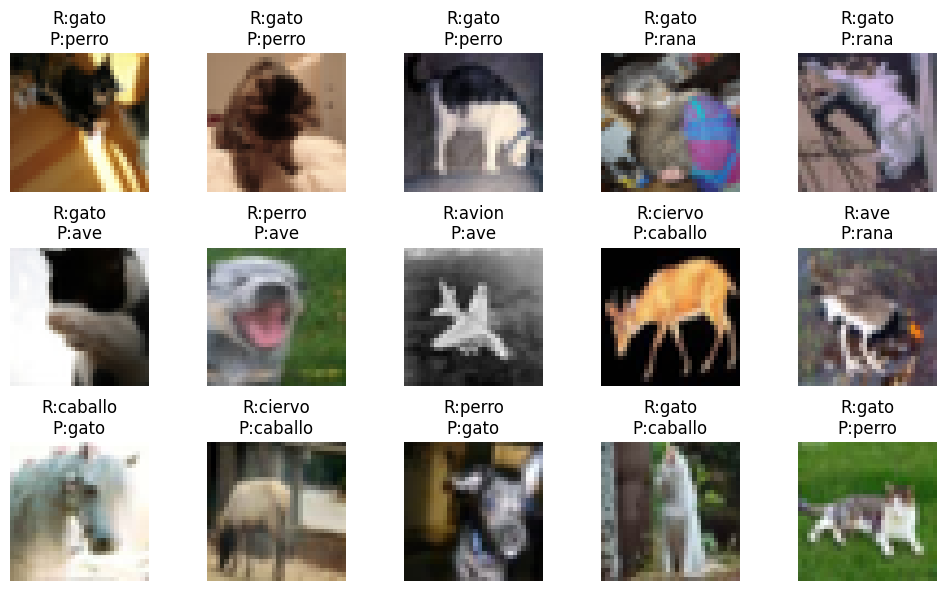

In [ ]:
# Evaluación del modelo con Data Augmentation
test_loss_cnn_aug, test_acc_cnn_aug = model_cnn_aug.evaluate(x_test, y_test_one_hot, verbose=0)
print(f"Accuracy en test (CNN deep + augmentation): {test_acc_cnn_aug:.4f}")

y_pred_cnn_aug_proba = model_cnn_aug.predict(x_test)
y_pred_cnn_aug = np.argmax(y_pred_cnn_aug_proba, axis=1)
y_true = y_test.flatten()

print("Classification report - CNN deep + augmentation:")
print(classification_report(
    y_true, y_pred_cnn_aug,
    target_names=[MAP_ELEMENTS[i] for i in range(num_classes)]
))

plot_confusion_matrix(
    y_true, y_pred_cnn_aug,
    class_names=[MAP_ELEMENTS[i] for i in range(num_classes)],
    title="Matriz de confusión - CNN deep + augmentation"
)

show_misclassified_images(x_test, y_true, y_pred_cnn_aug, n_images=15)

Finalmente, se ha aplicado Data Augmentation usando `ImageDataGenerator` con las siguientes transformaciones: Rotaciones aleatorias (rotation_range=15), pequeños desplazamientos horizontales y verticales (width_shift_range=0.1, height_shift_range=0.1) y Volteo horizontal (horizontal_flip=True).

Estas transformaciones generan versiones ligeramente modificadas de las imágenes de entrenamiento, incrementando la diversidad del conjunto de datos efectivo y ayudando al modelo a ser más robusto a variaciones de pose, posición y orientación.

Se ha reutilizado la arquitectura con BatchNorm y Dropout. Tras el entrenamiento, los resultados han dado un Accuracy en test de aproximadamente 0.843.

En comparación con la misma arquitectura sin Data Augmentation de aproximadamente 82.7%, se observa una mejora adicional en la capacidad de generalización. El modelo es menos sensible a variaciones pequeñas de las imágenes y aprende patrones más invariantes.

El classification report indica que las métricas especialmente altas en vehículos (`coche`, `barco`, `camion`), con precision y recall en muchos casos superiores al 0.9. Las clases de animales siguen siendo más difíciles, pero presentan mejoras respecto a modelos usados anteriormente.

## Conclusiones

En esta actividad se ha abordado el problema de clasificación de imágenes en el dataset CIFAR-10 utilizando diferentes arquitecturas de redes neuronales:

1. Un modelo Fully Connected ha servido como baseline, mostrando un rendimiento cercano al azar (de aproximadamente 11% de accuracy) y demostrando que este tipo de arquitectura no es adecuada para datos de tipo imagen.

2. Una primera CNN baseline que ha mejorado drásticamente la accuracy hasta aproximadamente 70%, poniendo de manifiesto la importancia de las convoluciones y del max-pooling para extraer patrones locales.

3. Una CNN más profunda con Batch Normalization y Dropout que ha alcanzado alrededor de 83% de accuracy en test. Esta arquitectura más rica permite aprender representaciones jerárquicas más potentes, mientras que la regularización controla el sobreajuste.

4. Finalmente, al añadir Data Augmentation a la CNN se ha obtenido el mejor resultado de aproximadamente 84% de accuracy, evidenciando que aumentar artificialmente la diversidad del conjunto de entrenamiento mejora la capacidad de generalización del modelo.

El análisis por clase y el estudio de las imágenes mal clasificadas muestran que:

- Las clases de vehículos se reconocen con alta precisión.
- Algunas clases de animales, especialmente `ave` y `gato`, resultan más difíciles, debido a variaciones de pose, tamaño en la imagen y fondos complejos.

En conjunto, la actividad permite comprobar de forma práctica cómo:

- El diseño de la arquitectura (profundidad, convoluciones, normalización, regularización).
- Y las estrategias de entrenamiento (data augmentation, early stopping, optimizadores adecuados)